In [125]:
import pandas as pd
import matplotlib.pyplot as plt
import osmnx as ox
import geopandas as gpd
pd.set_option("display.max_columns", 60)

In [153]:
gdf = gpd.read_file("M4_Tramos.geojson")
gdf = gdf.to_crs(epsg=25830)
estaciones = pd.read_csv("M4_Estaciones.csv")
paradas_itinerario = pd.read_csv("M4_ParadasPorItinerario.csv")
tramos = pd.read_csv("M4_Tramos.csv")

In [154]:
gdf['NUMEROLINEAUSUARIO'] = gdf['NUMEROLINEAUSUARIO'].str.replace("b", "", regex=False)
gdf['NUMEROLINEAUSUARIO'] = gdf['NUMEROLINEAUSUARIO'].str.replace("B", "", regex=False)
gdf['NUMEROLINEAUSUARIO'] = gdf['NUMEROLINEAUSUARIO'].str.replace("a", "", regex=False)
gdf['NUMEROLINEAUSUARIO'] = gdf['NUMEROLINEAUSUARIO'].str.replace("A", "", regex=False)
gdf['NUMEROLINEAUSUARIO'] = gdf['NUMEROLINEAUSUARIO'].str.replace("-1", "", regex=False)
gdf['NUMEROLINEAUSUARIO'] = gdf['NUMEROLINEAUSUARIO'].str.replace("-2", "", regex=False)

In [108]:
gdf['NUMEROLINEAUSUARIO'].unique()
colores_metro = {
    "1": "#30a3dc",
    "2": "#cd031f",
    "3": "#ffe114",
    "4": "#944248",
    "5": "#96bf0d",
    "6": "#9fa4a6",
    "7": "#faa64a",
    "8": "#f27ca2",
    "9": "#a3228d",
    "10": "#084594",
    "11": "#008b43",
    "12": "#a49a00"
}

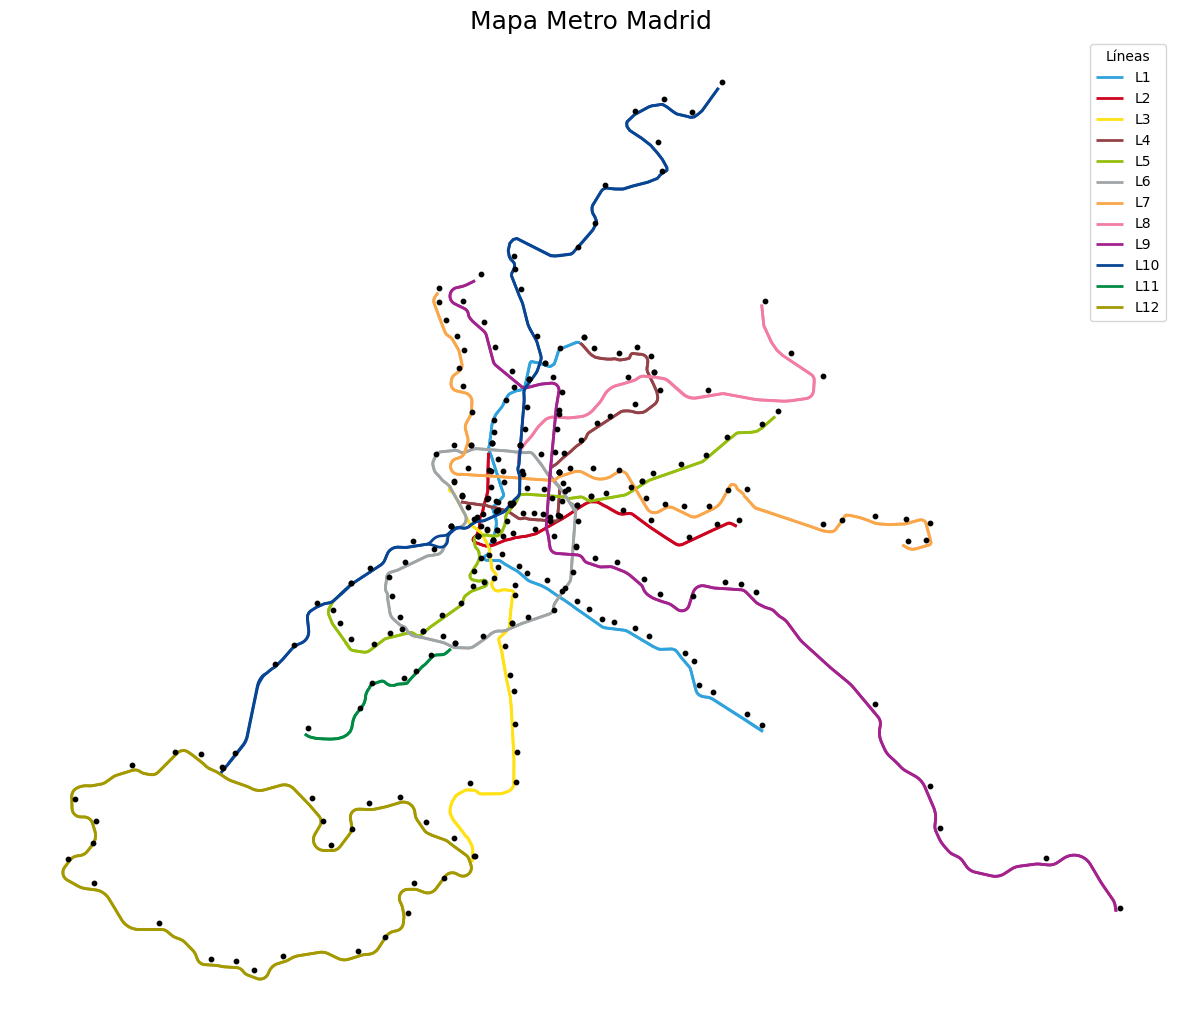

In [109]:
fig, ax = plt.subplots(figsize=(15,15))

for linea, color in colores_metro.items():
    subset = gdf[gdf["NUMEROLINEAUSUARIO"] == linea]
    if not subset.empty:
        subset.plot(
            ax=ax,
            color=color,
            linewidth=2,
            label=f"L{linea}"
        )

# estaciones
ax.scatter(estaciones["X"], estaciones["Y"], c="black", s=10, zorder=2)

ax.set_title("Mapa Metro Madrid", fontsize=18)
ax.axis("off")   # 👈 MUY IMPORTANTE estilo cartel
ax.legend(title="Líneas", loc="upper right")

plt.show()

In [ ]:
estaciones= estaciones[:-2]
estaciones = estaciones[['OBJECTID', 'DENOMINACION', "X", "Y", "LINEAS"]]
estaciones = estaciones.groupby(['DENOMINACION', 'LINEAS'])[['OBJECTID', 'X', 'Y']].min().reset_index()

In [122]:
estaciones

,DENOMINACION,LINEAS,OBJECTID,X,Y
0,ABRANTES,11,204,438322.0,4470489.0
1,ACACIAS,"3, 5",192,440147.0,4473032.0
2,AEROPUERTO T-4,8,94,449835.0,4482717.0
3,AEROPUERTO T1-T2-T3,8,51,451828.0,4480138.0
4,ALAMEDA DE OSUNA,5,96,450295.0,4478943.0
...,...,...,...,...,...
237,VILLA DE VALLECAS,1,241,447370.0,4470283.0
238,VILLAVERDE ALTO,3,75,439638.0,4466082.0
239,VILLAVERDE BAJO CRUCE,3,267,441289.0,4467142.0
240,VINATEROS,9,150,444727.0,4473704.0


In [155]:
gdf = gdf[['IDTRAMO', 'DENOMINACION', 'CODIGOESTACION', "NUMEROLINEAUSUARIO", 'CODIGOITINERARIO', 'SENTIDO', 'NUMEROORDEN', 'Shape__Length', 'geometry']]

In [168]:
def buscar_valor(row, df):
    coincidencia = df[(df['NUMEROLINEAUSUARIO'] == row['NUMEROLINEAUSUARIO']) & (df['SENTIDO'] == row['SENTIDO']) & (df['NUMEROORDEN'] == row['NUMEROORDEN'] - 1)]
    if not coincidencia.empty:
        return coincidencia['DENOMINACION'].values[0]
    else:
        exception = df[(df['NUMEROLINEAUSUARIO'] == row['NUMEROLINEAUSUARIO']) & (df['SENTIDO'] != row['SENTIDO'])].sort_values(by="NUMEROORDEN", ascending=False)
        return exception['DENOMINACION'].values[0] if not exception.empty else None

gdf['ESTACIONORIGEN'] = gdf.apply(buscar_valor, df=gdf, axis=1)

In [170]:
gdf[['IDTRAMO', 'ESTACIONORIGEN', 'DENOMINACION', 'CODIGOESTACION', 'NUMEROLINEAUSUARIO', 'CODIGOITINERARIO', 'SENTIDO', 'NUMEROORDEN', 'Shape__Length', 'geometry']]

,IDTRAMO,ESTACIONORIGEN,DENOMINACION,CODIGOESTACION,NUMEROLINEAUSUARIO,CODIGOITINERARIO,SENTIDO,NUMEROORDEN,Shape__Length,geometry
0,4_336284_278__755_I,LA MORALEJA,LA GRANJA,278,10,336284,1,7,2061.125447,"LINESTRING (446157.294 4486978.572, 446093.905..."
1,4_336285_278__756_I,RONDA DE LA COMUNICACION,LA GRANJA,278,10,336285,2,5,1497.636440,"LINESTRING (443892.294 4485176.37, 443940.036 ..."
2,4_336284_279__757_I,MARQUES DE LA VALDAVIA,LA MORALEJA,279,10,336284,1,6,1325.803853,"LINESTRING (445976.074 4488004.336, 446135.04 ..."
3,4_336285_279__758_I,LA GRANJA,LA MORALEJA,279,10,336285,2,6,2057.293680,"LINESTRING (444190.836 4486526.482, 444227.309..."
4,4_336284_280__759_I,MANUEL DE FALLA,MARQUES DE LA VALDAVIA,280,10,336284,1,5,1514.587660,"LINESTRING (445205.094 4489030.989, 445184.17 ..."
...,...,...,...,...,...,...,...,...,...,...
555,4_336284_282__763_I,FUENCARRAL,BAUNATAL,282,10,336284,1,3,1085.923240,"LINESTRING (447163.134 4489089.423, 446788.543..."
556,4_336285_282__764_I,MANUEL DE FALLA,BAUNATAL,282,10,336285,2,9,1112.442996,"LINESTRING (445203.087 4489032.996, 445334.004..."
557,4_336284_283__765_I,TRES OLIVOS,REYES CATOLICOS,283,10,336284,1,2,1556.359153,"LINESTRING (448235.397 4490076.805, 447666.856..."
558,4_336285_283__766_I,PRINCIPE PIO,REYES CATOLICOS,283,10,336285,2,10,1086.745470,"LINESTRING (446188.041 4489498.303, 446260.955..."


In [157]:
gdf.sort_values(by=["NUMEROLINEAUSUARIO", "SENTIDO", "NUMEROORDEN"])

,IDTRAMO,DENOMINACION,CODIGOESTACION,NUMEROLINEAUSUARIO,CODIGOITINERARIO,SENTIDO,NUMEROORDEN,Shape__Length,geometry
469,4_367770_262__721_I,BAMBU,262,1,367770,1,2,1061.401310,"LINESTRING (443445.628 4481277.651, 443400.033..."
492,4_367770_261__719_I,CHAMARTIN,261,1,367770,1,3,782.366351,"LINESTRING (442636.384 4480759.552, 442635.187..."
161,4_367770_1__5_I,PLAZA DE CASTILLA,1,1,367770,1,4,1190.465146,"LINESTRING (442050.619 4480575.559, 441785.901..."
163,4_367770_2__7_I,VALDEACEDERAS,2,1,367770,1,5,514.393042,"LINESTRING (441531.589 4479762.66, 441507.304 ..."
402,4_367770_3__9_I,TETUAN,3,1,367770,1,6,560.104657,"LINESTRING (441081.502 4479546.43, 441041.804 ..."
...,...,...,...,...,...,...,...,...,...
307,4_354330_161__338_I,HERRERA ORIA,161,9,354330,2,22,962.980592,"LINESTRING (440377.051 4480933.6, 440349.821 4..."
531,4_354330_326__1158_I,MIRASIERRA,326,9,354330,2,23,1212.742045,"LINESTRING (440003.335 4481792.307, 439992.591..."
532,4_354330_345__1207_C,PACO DE LUCIA,345,9,354330,2,24,1456.696615,"LINESTRING (439164.532 4482604.923, 439133.112..."
160,4_283064_238__3_T,PRINCIPE PIO,238,R,283064,1,2,994.450222,"LINESTRING (439801.373 4474375.035, 439794.31 ..."
